In [1]:
# Автоматическая перезагрузка модулей при изменении
# Это позволяет обновлять код в helper.py, plots.py, nlp.py без перезапуска ядра
%load_ext autoreload
%autoreload 2

In [2]:
# Импорт необходимых библиотек для анализа данных
import pandas as pd  # для работы с табличными данными
import numpy as np   # для математических операций
import random        # для работы с генератором случайных чисел

# Импорт пользовательских модулей с функциями для анализа
from helper import *  # вспомогательные функции для обработки данных
from plots import *   # функции для визуализации
from nlp import *     # функции для обработки естественного языка

In [3]:
# Фиксация состояния генератора псевдослучайных чисел для воспроизводимости результатов
# Это критически важно для машинного обучения - результаты должны быть воспроизводимы
SEED = 42 # можно указать любое число
np.random.seed(SEED)  # для numpy операций
random.seed(SEED)     # для стандартного модуля random

## 1. Изучение структуры данных

Цель: Понять общую структуру датасета, количество записей, типы данных и качество информации.

In [4]:
# Загружаем данные из CSV файла
df = pd.read_csv('Data/movie.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB


## 2. Проверка на корректность и качество данных

### 2.1 Проверка на дубликаты

In [6]:
df.duplicated().sum()

np.int64(277)

In [9]:
# удалим дубликаты
df = df.drop_duplicates()

### 2.2 Пропущенные значения

In [10]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [11]:
# Анализ коротких описаний (менее 100 символов)
# Короткие описания могут быть неинформативными или содержать служебную информацию
short_texts = df[df['text'].str.len() < 100]
short_texts['text'].value_counts()

text
I don't know why I like this movie so well, but I never get tired of watching it.                     1
no comment - stupid movie, acting average or worse... screenplay - no sense at all... SKIP IT!        1
Ming The Merciless does a little Bardwork and a movie most foul!                                      1
A rating of "1" does not begin to express how dull, depressing and relentlessly bad this movie is.    1
If you like Pauly Shore, you'll love Son in Law. If you hate Pauly Shore, then, well...I liked it!    1
You'd better choose Paul Verhoeven's even if you have watched it.                                     1
Just love the interplay between two great characters of stage & screen - Veidt & Barrymore            1
More suspenseful, more subtle, much, much more disturbing....                                         1
What a script, what a story, what a mess!                                                             1
Long, boring, blasphemous. Never have I been so glad to see

## 3. Детальное изучение признаков (и таргета)

In [12]:
# Создаем копию датасета для EDA, чтобы не изменять исходные данные
# Это позволяет безопасно экспериментировать с данными
df_EDA = df.copy()

### 3.1. Таргет (целевая переменная)

In [13]:
# Анализируем распределение целевой переменной (label)
# Ham - не спам, Spam - спам
# Смотрим, насколько сбалансированы классы
df_EDA['label'].value_counts()

label
1    19908
0    19815
Name: count, dtype: int64

### 3.2. Анализ тестов (text)

In [14]:
# Анализ длины описаний в символах
# Описания обычно длиннее заголовков и содержат больше информации
df_EDA['description_char_length'] = df_EDA['text'].str.len()

In [15]:
# Статистическое описание длины описаний
# Описания значительно длиннее заголовков, что ожидаемо
df_EDA['description_char_length'].describe()

count    39723.000000
mean      1311.169197
std        989.292967
min         32.000000
25%        698.000000
50%        973.000000
75%       1597.000000
max      13704.000000
Name: description_char_length, dtype: float64

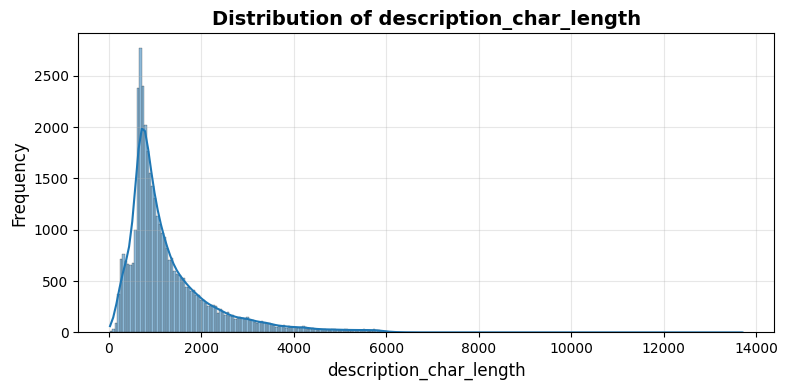

In [ ]:
# Распределение длины описаний
plot_hist_numeric(df_EDA, 'description_char_length')

In [18]:
# Токенизация текстов
df_EDA['description_tokenized_tiktoken'] = df_EDA['text'].apply(tokenize_tiktoken)
df_EDA['description_tokenized_tiktoken_len'] = df_EDA['description_tokenized_tiktoken'].apply(len)

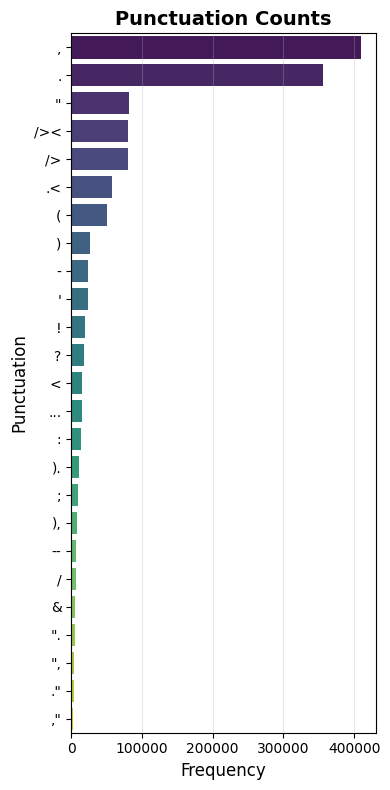

In [19]:
# Анализ знаков пунктуации в описаниях
# Многие описания в markdown формате, поэтому знаки пунктуации могут быть информативными
punctuation_counts = punctuation_counts(df_EDA, 'description_tokenized_tiktoken')
barplot(punctuation_counts, title='Punctuation Counts', ylabel='Punctuation', top_n=25, figsize=(4, 8))

Видим, что лидируют запятые и точки, но на 3 месте находятся кавычки, возможно это связано с тем, что комментариях встречаются названия различных произведений. 

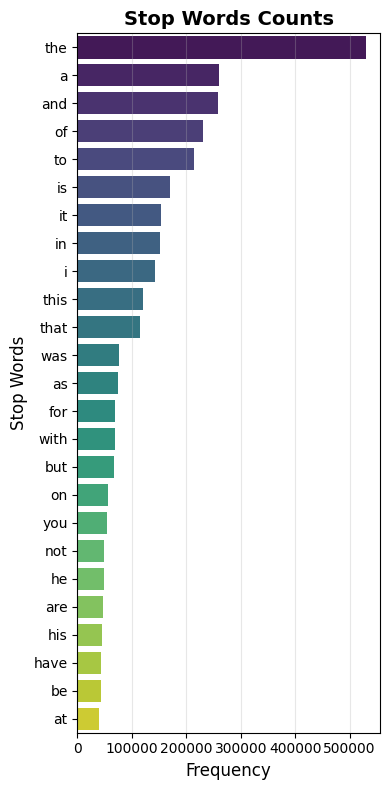

In [20]:
# Анализ стоп-слов в описаниях
# Стоп-слова (артикли, предлоги, союзы) обычно удаляются при обработке текста
stop_words_counts = stopwords_count(df_EDA, 'description_tokenized_tiktoken')
barplot(stop_words_counts, title='Stop Words Counts', ylabel='Stop Words', top_n=25, figsize=(4, 8))

In [21]:
# Подсчет частотности токенов в описаниях (без стоп-слов и пунктуации)
# Это поможет выявить ключевые термины
token_counts = token_counts(
    df_EDA, 
    'description_tokenized_tiktoken', 
    remove_stopwords=True, 
    remove_punctuation=True,
    lowercase_for_counting=True
)

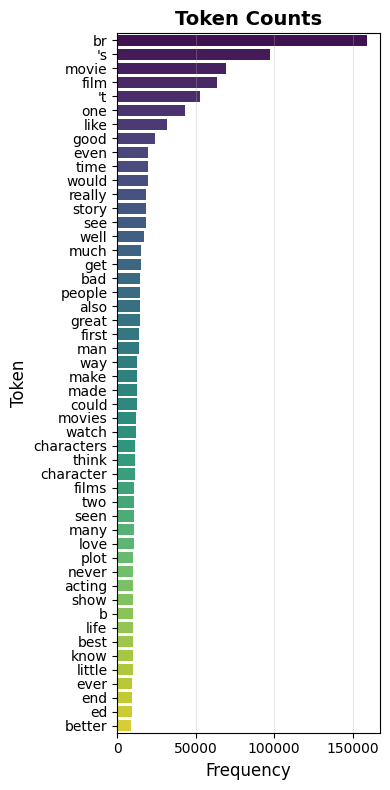

In [ ]:
# Топ-50 самых частых токенов в описаниях
barplot(token_counts, title='Token Counts', ylabel='Token', top_n=50, figsize=(4, 8))

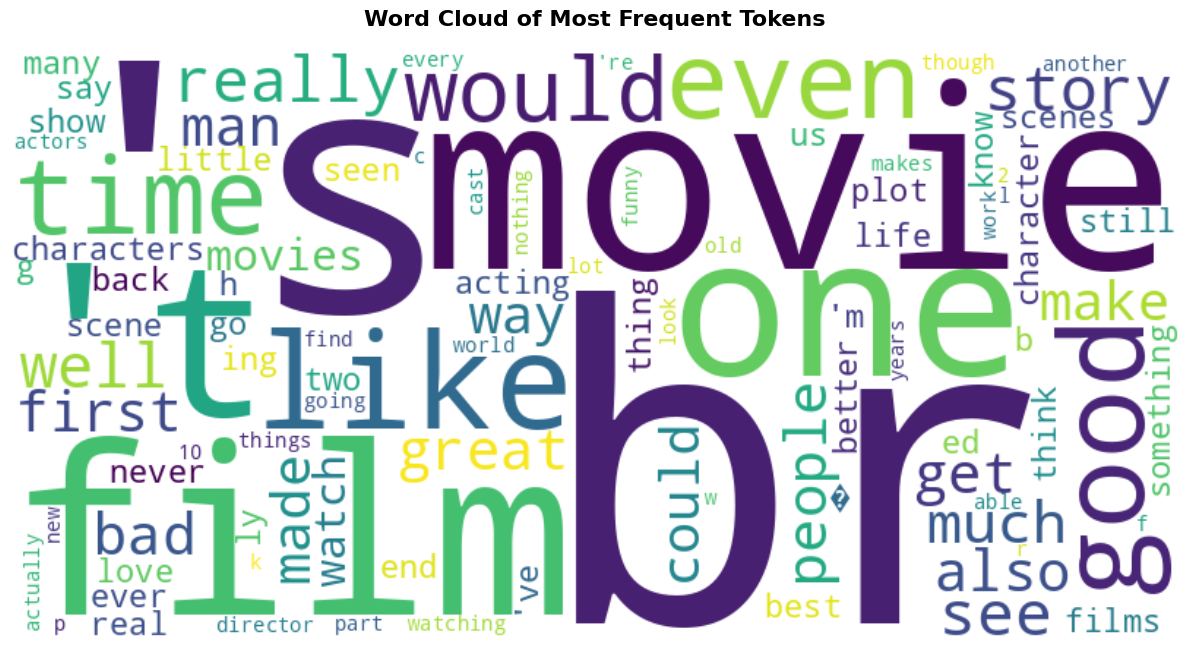

In [23]:
# Облако слов для описаний
plot_wordcloud(token_counts, title='Word Cloud of Most Frequent Tokens', max_words=100)

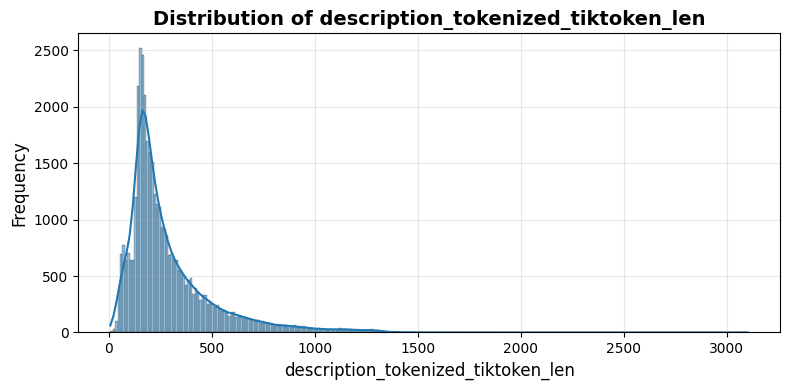

In [24]:
# Распределение количества токенов в описаниях
plot_hist_numeric(df_EDA, 'description_tokenized_tiktoken_len')

In [25]:
# Очистка токенов описаний: удаляем стоп-слова и пунктуацию
# Подготавливаем данные для анализа важности токенов
df_EDA['description_tokenized_tiktoken_clean'] = df_EDA['description_tokenized_tiktoken'].apply(lambda tokens: filter_tokens(
    tokens, 
    remove_stopwords=True, 
    remove_punct_tokens=True,
    lowercase_for_counting=True
))

In [27]:
# Анализ важности токенов в описаниях для классификации
# Это самый важный анализ - выявляем, какие слова и фразы лучше всего различают позитивный или негативный комментарий 
# n=3: анализируем 1-граммы, 2-граммы и 3-граммы
counts = count_based_analysis(
    texts_tokenized = df_EDA['description_tokenized_tiktoken_clean'], 
    labels = df_EDA['label'], 
    n=3,
    metric='anova_f',
    min_count=50
)

In [28]:
# Выводим результаты анализа важности токенов
# Чем выше значение метрики, тем важнее токен для классификации
counts

,token,metric,count_0,freq_0,count_1,freq_1,total_count
0,bad,2.848093e+03,11695,0.001396,3035,0.000350,14730
1,worst,2.275692e+03,3719,0.000444,339,0.000039,4058
2,great,1.737093e+03,4093,0.000489,10320,0.001189,14413
3,waste,1.526109e+03,2031,0.000242,129,0.000015,2160
4,awful,1.256033e+03,2283,0.000272,236,0.000027,2519
...,...,...,...,...,...,...,...
19737,film really,7.808062e-06,226,0.000027,227,0.000026,453
19738,ey,6.791385e-06,450,0.000054,452,0.000052,902
19739,luck,7.932732e-07,209,0.000025,210,0.000024,419
19740,lots,1.397426e-07,636,0.000076,639,0.000074,1275


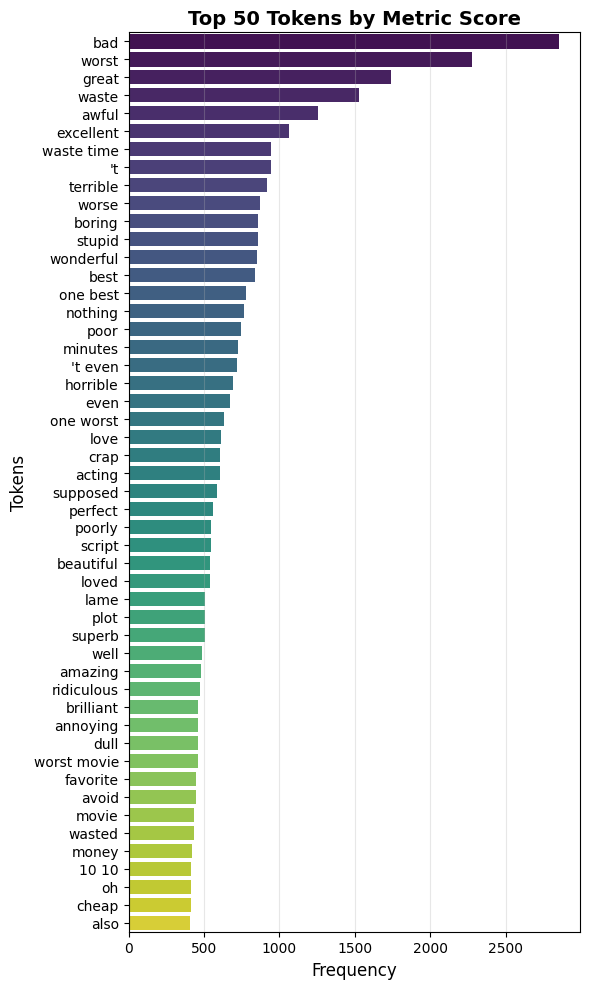

In [29]:
# Визуализация топ-50 наиболее важных для классификации токенов в описаниях
barplot_data_metric = counts.set_index('token')['metric'].head(50)
barplot(barplot_data_metric, 'Top 50 Tokens by Metric Score', 'Tokens', figsize=(6, 10))

Очевидно видим описательные прилагательные.